# Three-Variable Keller-Segel Slime Mold Chemotaxis Simulation

Simulating *Dictyostelium* chemotaxis with separate **self-produced chemoattractant** (cAMP) and **external nutrient** using a three-variable Keller-Segel model solved on a 2D finite-volume grid.

**Computational backend:** C++ (Eigen SparseLU + Scharfetter-Gummel scheme, via pybind11) when available; falls back to FiPy automatically.

**Three Coupled PDEs:**
- Cell density: $\partial\rho/\partial t = D_\rho \nabla^2\rho - \chi(1 - \rho/\rho_{\max}) \nabla\cdot(\rho \nabla c) + \frac{\mu_{\max}}{Y} s \, \rho (1 - \rho/\rho_{\max})$
- cAMP chemoattractant (quasi-steady-state): $0 = D_c \nabla^2 c - \beta c + \alpha \rho$
- Nutrient/substrate (quasi-steady-state): $0 = D_s \nabla^2 s - \mu_{\max} s \, \rho$

**Key biological separation:**
- **cAMP (c)**: self-produced by cells (rate α), no-flux BCs — drives chemotactic aggregation via positive feedback
- **Nutrient (s)**: externally supplied at boundaries (Dirichlet BCs), consumed by cells — drives growth

**Volume-filling** (Painter & Hillen 2002): the factor $(1 - \rho/\rho_{\max})$ suppresses both chemotaxis and growth as density approaches the carrying capacity, preventing finite-time blow-up.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

from keller_segel import DimensionalParams, KellerSegelParams, run_simulation, _HAS_CPP

backend = "C++ (Eigen SparseLU)" if _HAS_CPP else "FiPy"
print(f"Solver backend : {backend}")

Solver backend : C++ (Eigen SparseLU)


## Parameter Configuration

Parameters are set via `DimensionalParams` in physical units and converted to the dimensionless form used by the FiPy solver via `.to_dimensionless()`.

**Non-dimensionalization reference scales** (cAMP equation fixes all scales):

| Scale | Formula | Value |
|-------|---------|-------|
| Length L₀ | √(D_c / β) | 0.219 mm |
| Time T₀ | 1 / β | 2 min |
| cAMP c₀ | c_ref | 10 nM |
| Cell density ρ₀ | ρ_max | 10⁴ cells/mm² |
| Nutrient s₀ | s_boundary | 2 µg/mL |

**Physical parameters and resulting dimensionless solver values:**

| Parameter | Physical value | Units | Code value | Source |
|-----------|---------------|-------|-----------|--------|
| `D_c` | 0.024 | mm²/min (= 400 µm²/s) | 1.0 (reference) | Tomchik & Devreotes 1981 |
| `beta` | 0.5 | min⁻¹ | 1.0 (reference) | Martiel & Goldbeter 1987 |
| `alpha` | derived | nM·mm²/(cell·min) | 1.0 (derived) | c_ref · β / ρ_max |
| `D_rho` | 5×10⁻⁵ | mm²/min (= 50 µm²/min) | 0.0021 | Devreotes & Zigmond 1988 |
| `chi` | 1.8×10⁻³ | mm²/(nM·min) | 0.75 | Van Haastert & Veltman 2007 |
| `D_s` | 0.012 | mm²/min (= 200 µm²/s) | 0.5 | small-molecule diffusion |
| `mu_max` | 0.002 | min⁻¹ (≈ 5.8 hr doubling) | 0.004 | AX2 on bacteria |
| `K_s` | 0.5 | µg/mL | Y = 0.25 | Monod half-saturation |
| `rho_max` | 10⁴ | cells/mm² | 1.0 (reference) | close-packed monolayer |
| `s_boundary` | 2.0 | µg/mL | 1.0 (reference) | Dirichlet BC |

Two presets are available:
- `DimensionalParams.aggregation_phase()` — starved cells, χ = 1.8×10⁻³, no nutrient, 2 hr
- `DimensionalParams.growth_phase()` — dividing cells, χ = 1.8×10⁻⁴ (10× weaker), 10 hr

In [2]:
# =============================================================================
# Phase 1: Growth — cells divide on nutrient, weak chemotaxis (10 hr)
# =============================================================================
dim_growth = DimensionalParams.growth_phase()
dim_growth.n_bumps = 10
dim_growth.rho_bump_seed = 42
dim_growth.total_time_min = 300  # 5 hr to see colony growth
params_growth = dim_growth.to_dimensionless()

print("=== Phase 1: Growth ===")
print(f"Domain         : {dim_growth.Lx_mm} × {dim_growth.Ly_mm} mm  ({params_growth.nx}×{params_growth.ny} cells)")
print(f"Physical time  : {dim_growth.total_time_min:.0f} min ({dim_growth.total_time_min/60:.0f} hr)")
print(f"chi            : {dim_growth.chi_mm2_per_nM_per_min:.1e} (weak — growth-dominated)")
print(f"mu_max         : {dim_growth.mu_max_per_min:.4f} min⁻¹ ({0.693/dim_growth.mu_max_per_min/60:.1f} hr doubling)")
print(f"s_boundary     : {dim_growth.s_boundary_ug_per_mL} µg/mL")

=== Phase 1: Growth ===
Domain         : 5.0 × 5.0 mm  (100×100 cells)
Physical time  : 300 min (5 hr)
chi            : 1.8e-04 (weak — growth-dominated)
mu_max         : 0.0020 min⁻¹ (5.8 hr doubling)
s_boundary     : 2.0 µg/mL


## Run Growth Phase

In [3]:
t0 = time.perf_counter()
result_growth = run_simulation(params_growth, progbar=True)
elapsed_growth = time.perf_counter() - t0

print(f"Backend        : {backend}")
print(f"Wall time      : {elapsed_growth:.1f} s")
print(f"Snapshots      : {len(result_growth.times)}")
print(f"Final mass     : {result_growth.total_mass[-1]:.2f}")
print(f"Final max ρ    : {result_growth.max_density[-1]:.4f}")

C++ solver:   0%|          | 0/7500 [00:00<?, ?step/s]

Backend        : C++ (Eigen SparseLU)
Wall time      : 733.3 s
Snapshots      : 151
Final mass     : 73.02
Final max ρ    : 0.2322


## Growth Phase: Snapshots

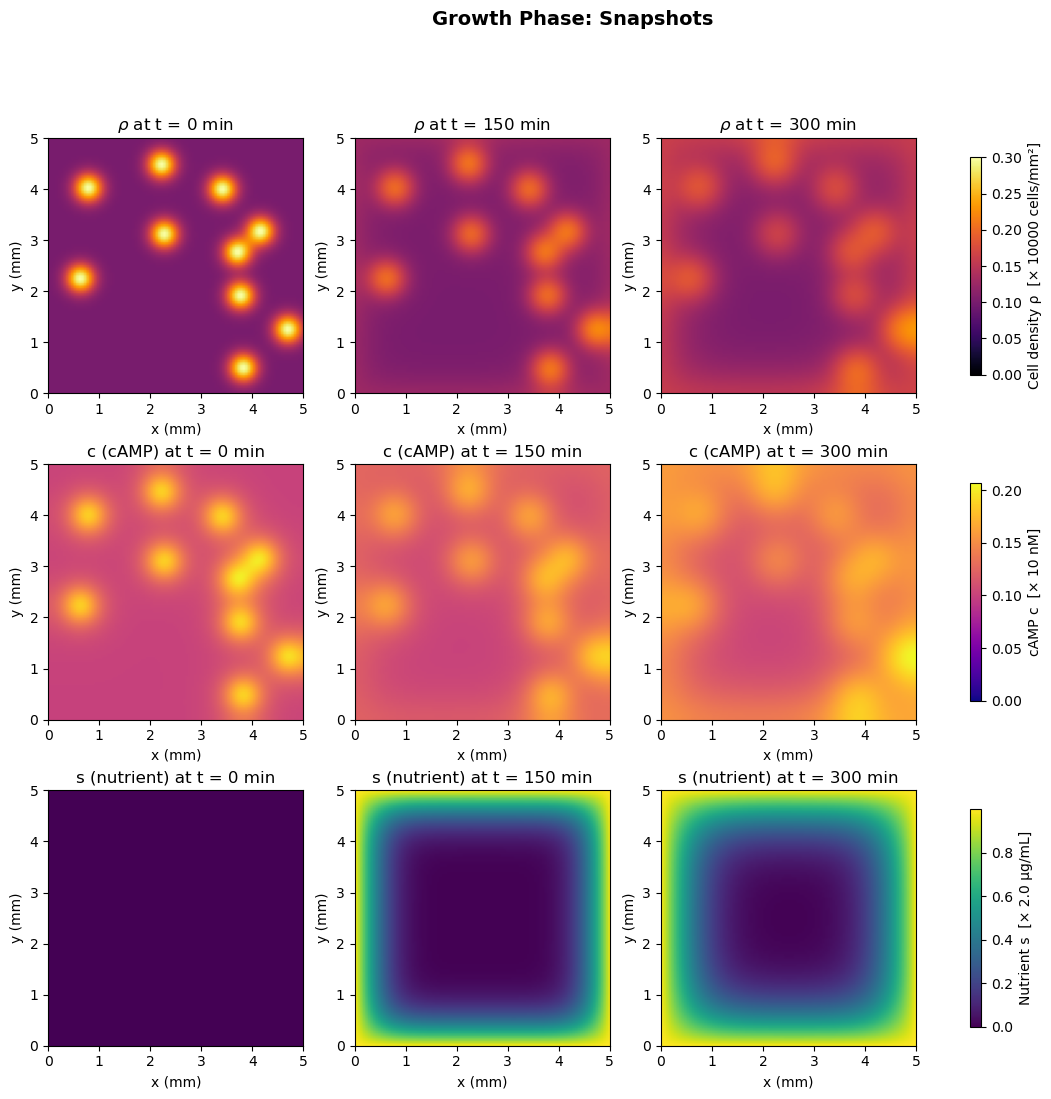

In [4]:
def plot_snapshots(result, dim, title_prefix=""):
    """Plot 3×3 snapshot grid for a simulation result."""
    n_snapshots = len(result.times)
    indices = [0, n_snapshots // 2, n_snapshots - 1]

    fig, axes = plt.subplots(3, 3, figsize=(14, 12))

    rho_vmax = max(snap.max() for snap in result.rho_snapshots)
    c_vmax   = max(snap.max() for snap in result.c_snapshots)
    s_vmax   = max(snap.max() for snap in result.s_snapshots) or 1.0

    extent_mm = [0, dim.Lx_mm, 0, dim.Ly_mm]

    for col, idx in enumerate(indices):
        t_min = result.times[idx] * dim.T0_min

        im_rho = axes[0, col].imshow(
            result.rho_snapshots[idx], origin="lower", extent=extent_mm,
            cmap="inferno", vmin=0, vmax=rho_vmax,
        )
        axes[0, col].set_title(f"$\\rho$ at t = {t_min:.0f} min")
        axes[0, col].set_xlabel("x (mm)")
        axes[0, col].set_ylabel("y (mm)")

        im_c = axes[1, col].imshow(
            result.c_snapshots[idx], origin="lower", extent=extent_mm,
            cmap="plasma", vmin=0, vmax=c_vmax,
        )
        axes[1, col].set_title(f"c (cAMP) at t = {t_min:.0f} min")
        axes[1, col].set_xlabel("x (mm)")
        axes[1, col].set_ylabel("y (mm)")

        im_s = axes[2, col].imshow(
            result.s_snapshots[idx], origin="lower", extent=extent_mm,
            cmap="viridis", vmin=0, vmax=s_vmax,
        )
        axes[2, col].set_title(f"s (nutrient) at t = {t_min:.0f} min")
        axes[2, col].set_xlabel("x (mm)")
        axes[2, col].set_ylabel("y (mm)")

    fig.colorbar(im_rho, ax=axes[0, :], label=f"Cell density ρ  [× {dim.rho_max_cells_per_mm2:.0f} cells/mm²]", shrink=0.8)
    fig.colorbar(im_c,   ax=axes[1, :], label=f"cAMP c  [× {dim.c_ref_nM:.0f} nM]", shrink=0.8)
    s_label = f"Nutrient s  [× {dim.s_boundary_ug_per_mL:.1f} µg/mL]" if dim.s_boundary_ug_per_mL > 0 else "Nutrient s  [dimensionless]"
    fig.colorbar(im_s,   ax=axes[2, :], label=s_label, shrink=0.8)
    fig.suptitle(f"{title_prefix}Snapshots", fontsize=14, fontweight="bold")
    return fig


def plot_diagnostics(result, dim, params, title_prefix=""):
    """Plot total mass and max density over time."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    n_diag = len(result.total_mass)
    t_min_diag = np.linspace(0, dim.total_time_min, n_diag)

    ax1.plot(t_min_diag, result.total_mass, color="steelblue", linewidth=1)
    ax1.set_xlabel("Time (min)")
    ax1.set_ylabel("Total mass  $\\int \\rho\\, dA$  [dimensionless]")
    ax1.set_title(f"{title_prefix}Total Cell Mass")
    ax1.grid(True, alpha=0.3)

    ax2.plot(t_min_diag, result.max_density, color="firebrick", linewidth=1)
    ax2.axhline(y=params.rho_max, color="gray", linestyle="--",
                label=f"$\\rho_{{max}}$ = {params.rho_max}")
    ax2.set_xlabel("Time (min)")
    ax2.set_ylabel("Max density  $\\rho_\\mathrm{max}$  [dimensionless]")
    ax2.set_title(f"{title_prefix}Max Cell Density")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    return fig


fig = plot_snapshots(result_growth, dim_growth, title_prefix="Growth Phase: ")
fig.savefig("snapshots_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## Growth Phase: Diagnostics

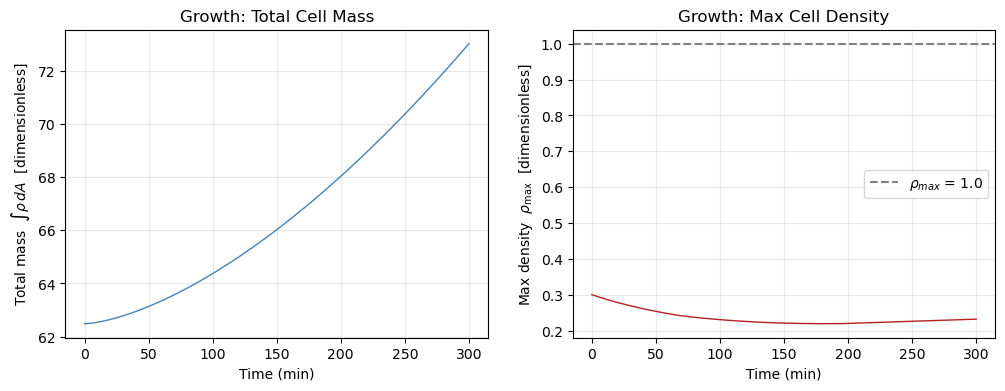

In [5]:
fig = plot_diagnostics(result_growth, dim_growth, params_growth, title_prefix="Growth: ")
fig.savefig("diagnostics_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 2: Aggregation

Nutrient is removed (starvation), triggering strong cAMP relay. The final cell density from growth phase is used as the initial condition — cells aggregate from wherever they grew to.

In [6]:
# Chain: use growth's final ρ (in physical units) as aggregation IC
final_rho_physical = result_growth.rho_snapshots[-1] * dim_growth.rho_max_cells_per_mm2

dim_agg = DimensionalParams(
    chi_mm2_per_nM_per_min=1.8e-3,   # full aggregation-phase sensitivity
    mu_max_per_min=0.0,               # no growth during starvation
    s_boundary_ug_per_mL=0.0,         # no nutrient at boundaries
    total_time_min=120.0,             # 2 hours to see aggregation
    rho_initial_cells_per_mm2=final_rho_physical,
)
params_agg = dim_agg.to_dimensionless()

print("=== Phase 2: Aggregation ===")
print(f"Physical time  : {dim_agg.total_time_min:.0f} min ({dim_agg.total_time_min/60:.1f} hr)")
print(f"chi            : {dim_agg.chi_mm2_per_nM_per_min:.1e} (strong — aggregation)")
print(f"mu_max         : {dim_agg.mu_max_per_min} (no growth)")
print(f"s_boundary     : {dim_agg.s_boundary_ug_per_mL} µg/mL (starved)")
print(f"IC from growth : max ρ = {final_rho_physical.max():.0f} cells/mm²")

=== Phase 2: Aggregation ===
Physical time  : 120 min (2.0 hr)
chi            : 1.8e-03 (strong — aggregation)
mu_max         : 0.0 (no growth)
s_boundary     : 0.0 µg/mL (starved)
IC from growth : max ρ = 2322 cells/mm²


## Run Aggregation Phase

In [7]:
t0 = time.perf_counter()
result_agg = run_simulation(params_agg, progbar=True)
elapsed_agg = time.perf_counter() - t0

print(f"Backend        : {backend}")
print(f"Wall time      : {elapsed_agg:.1f} s")
print(f"Snapshots      : {len(result_agg.times)}")
print(f"Final mass     : {result_agg.total_mass[-1]:.2f}")
print(f"Final max ρ    : {result_agg.max_density[-1]:.4f}")

C++ solver:   0%|          | 0/3000 [00:00<?, ?step/s]

Backend        : C++ (Eigen SparseLU)
Wall time      : 293.6 s
Snapshots      : 61
Final mass     : 73.02
Final max ρ    : 0.1712


## Aggregation Phase: Snapshots

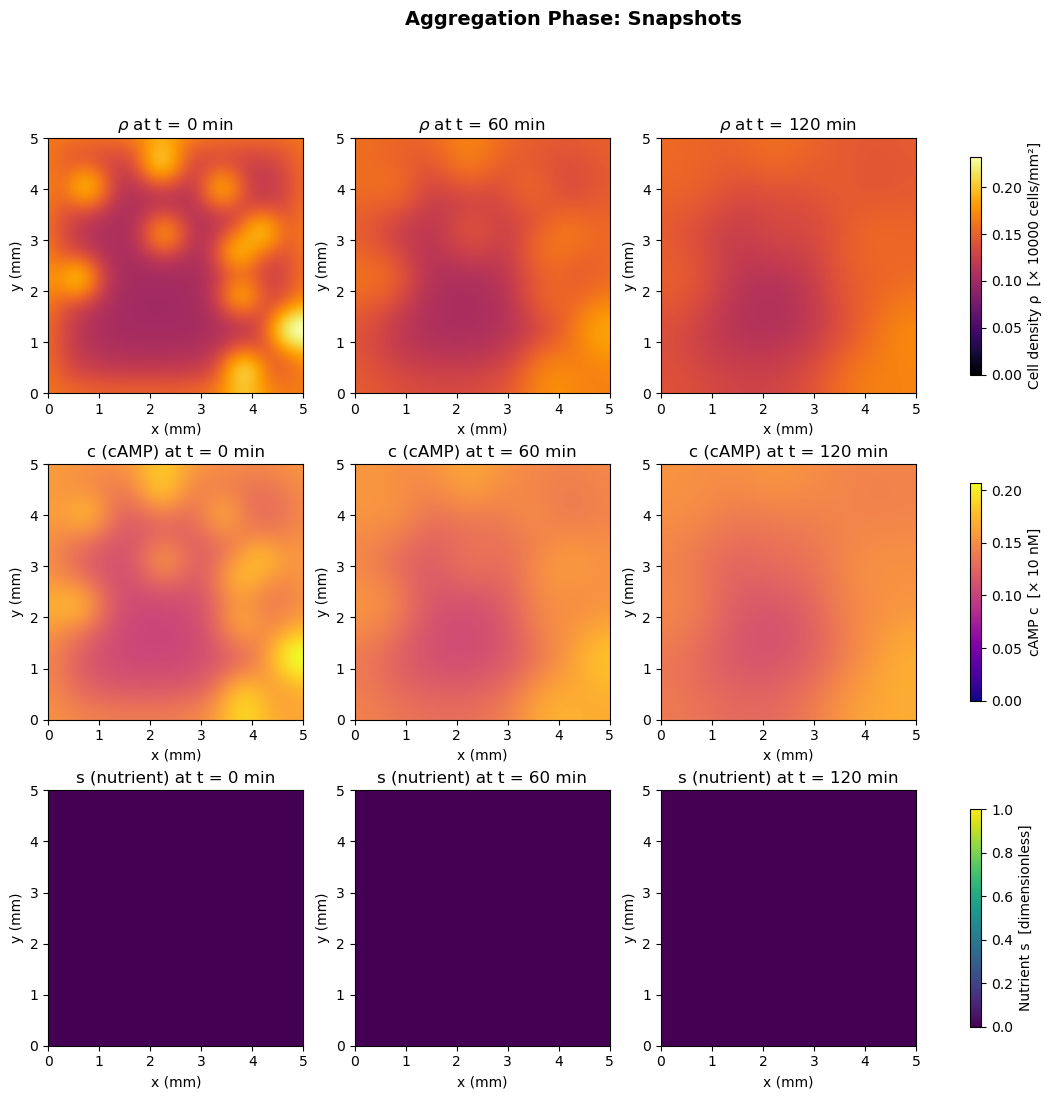

In [8]:
fig = plot_snapshots(result_agg, dim_agg, title_prefix="Aggregation Phase: ")
fig.savefig("snapshots_agg.png", dpi=150, bbox_inches="tight")
plt.show()

## Aggregation Phase: Diagnostics

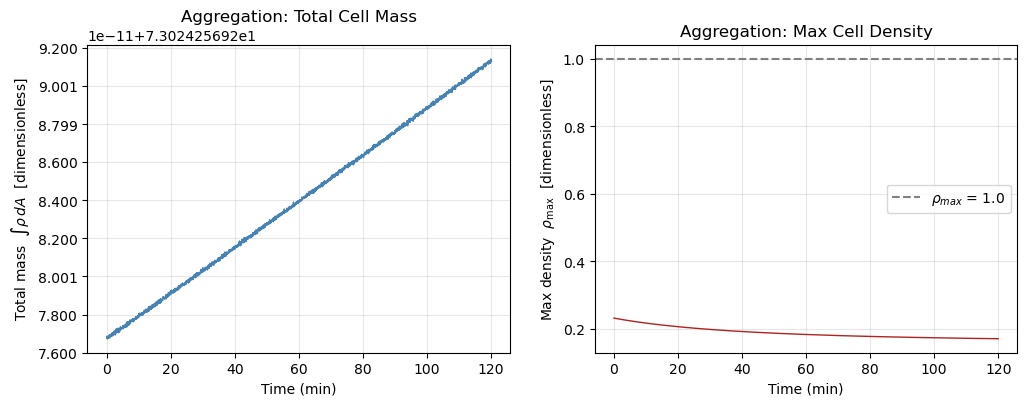

In [9]:
fig = plot_diagnostics(result_agg, dim_agg, params_agg, title_prefix="Aggregation: ")
fig.savefig("diagnostics_agg.png", dpi=150, bbox_inches="tight")
plt.show()

## Animation: Growth + Aggregation Phases

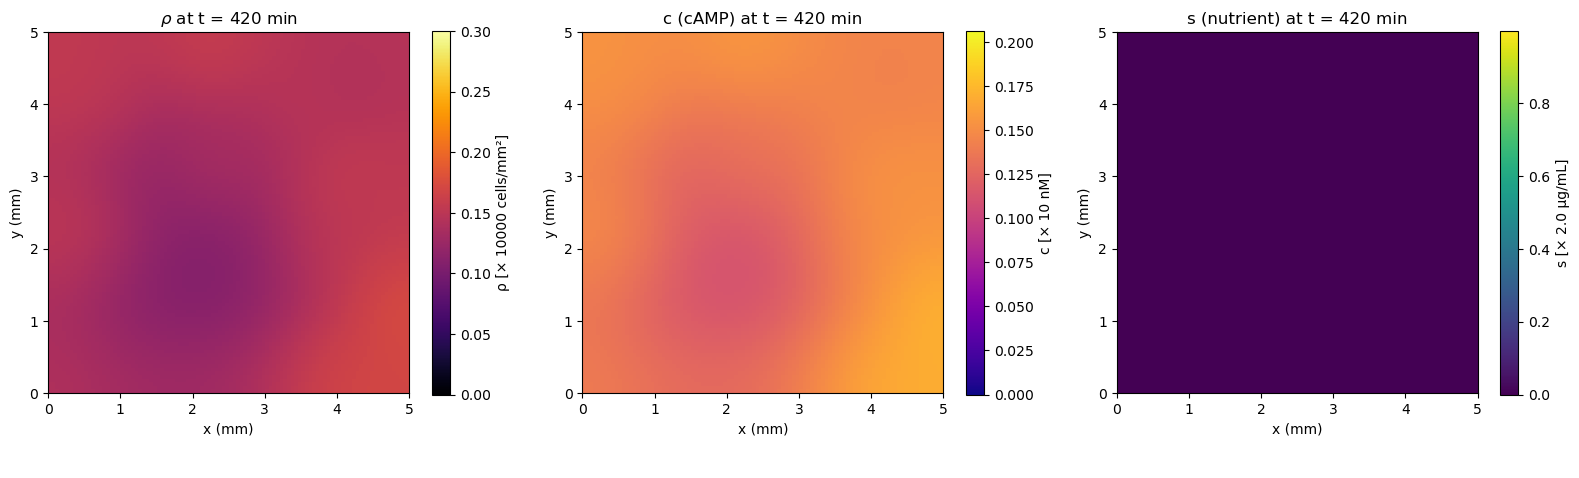

In [10]:
# Concatenate snapshots from both phases with continuous time
t_offset = dim_growth.total_time_min  # aggregation times start after growth

all_rho = result_growth.rho_snapshots + result_agg.rho_snapshots
all_c   = result_growth.c_snapshots   + result_agg.c_snapshots
all_s   = result_growth.s_snapshots   + result_agg.s_snapshots
all_t_min = (
    [t * dim_growth.T0_min for t in result_growth.times]
    + [t * dim_agg.T0_min + t_offset for t in result_agg.times]
)

# Use global vmax across both phases for consistent color scales
rho_vmax = max(snap.max() for snap in all_rho)
c_vmax   = max(snap.max() for snap in all_c)
s_vmax   = max(snap.max() for snap in all_s) or 1.0

extent_mm = [0, dim_growth.Lx_mm, 0, dim_growth.Ly_mm]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

im1 = ax1.imshow(all_rho[0], origin="lower", extent=extent_mm,
                 cmap="inferno", vmin=0, vmax=rho_vmax)
ax1.set_xlabel("x (mm)"); ax1.set_ylabel("y (mm)")
fig.colorbar(im1, ax=ax1, label=f"ρ [× {dim_growth.rho_max_cells_per_mm2:.0f} cells/mm²]", shrink=0.8)

im2 = ax2.imshow(all_c[0], origin="lower", extent=extent_mm,
                 cmap="plasma", vmin=0, vmax=c_vmax)
ax2.set_xlabel("x (mm)"); ax2.set_ylabel("y (mm)")
fig.colorbar(im2, ax=ax2, label=f"c [× {dim_growth.c_ref_nM:.0f} nM]", shrink=0.8)

im3 = ax3.imshow(all_s[0], origin="lower", extent=extent_mm,
                 cmap="viridis", vmin=0, vmax=s_vmax)
ax3.set_xlabel("x (mm)"); ax3.set_ylabel("y (mm)")
fig.colorbar(im3, ax=ax3, label=f"s [× {dim_growth.s_boundary_ug_per_mL:.1f} µg/mL]", shrink=0.8)

# Phase label
n_growth = len(result_growth.times)
phase_text = fig.text(0.5, 0.01, "", ha="center", fontsize=11, fontstyle="italic")

plt.tight_layout(rect=[0, 0.03, 1, 1])

def animate(frame):
    t = all_t_min[frame]
    phase = "Growth" if frame < n_growth else "Aggregation"
    im1.set_data(all_rho[frame])
    im2.set_data(all_c[frame])
    im3.set_data(all_s[frame])
    ax1.set_title(f"$\\rho$ at t = {t:.0f} min")
    ax2.set_title(f"c (cAMP) at t = {t:.0f} min")
    ax3.set_title(f"s (nutrient) at t = {t:.0f} min")
    phase_text.set_text(f"Phase: {phase}")
    return [im1, im2, im3, phase_text]

anim = animation.FuncAnimation(fig, animate, frames=len(all_rho),
                               interval=100, blit=True)
HTML(anim.to_html5_video())

## Combined: Growth + Aggregation Diagnostics

Side-by-side diagnostics across both phases. Time axis is continuous: growth (0–600 min) then aggregation (600–720 min).

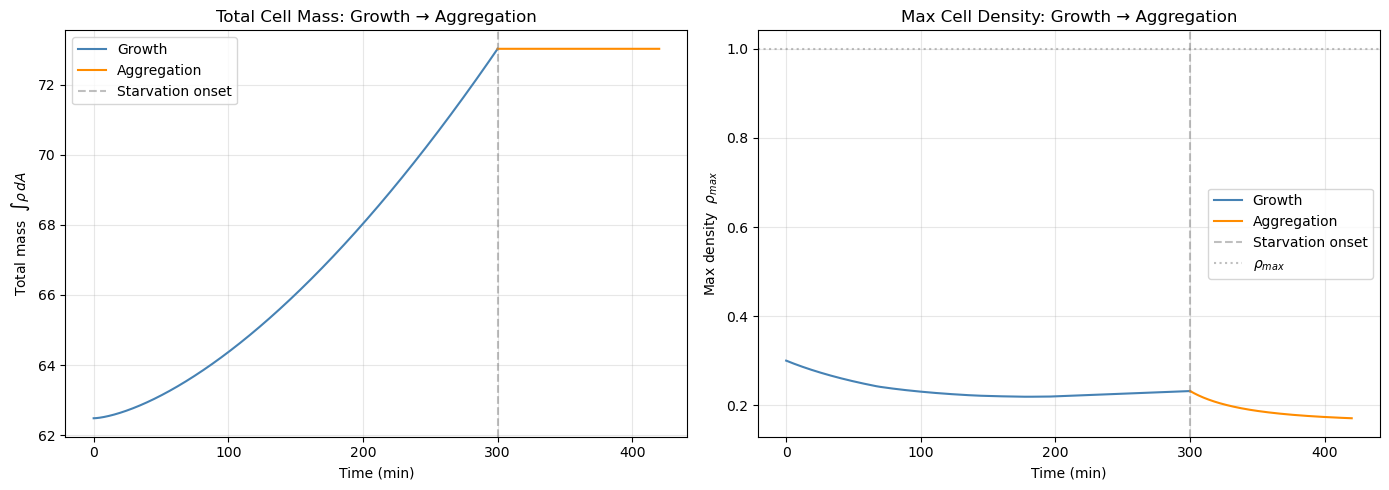


Total wall time: 1026.8 s (growth 733.3 s + aggregation 293.6 s)


In [11]:
# Build continuous time axis across both phases
t_growth = np.linspace(0, dim_growth.total_time_min, len(result_growth.total_mass))
t_agg = np.linspace(
    dim_growth.total_time_min,
    dim_growth.total_time_min + dim_agg.total_time_min,
    len(result_agg.total_mass),
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Total mass
ax1.plot(t_growth, result_growth.total_mass, color="steelblue", linewidth=1.5, label="Growth")
ax1.plot(t_agg, result_agg.total_mass, color="darkorange", linewidth=1.5, label="Aggregation")
ax1.axvline(x=dim_growth.total_time_min, color="gray", linestyle="--", alpha=0.5, label="Starvation onset")
ax1.set_xlabel("Time (min)")
ax1.set_ylabel("Total mass  $\\int \\rho\\, dA$")
ax1.set_title("Total Cell Mass: Growth → Aggregation")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Max density
ax2.plot(t_growth, result_growth.max_density, color="steelblue", linewidth=1.5, label="Growth")
ax2.plot(t_agg, result_agg.max_density, color="darkorange", linewidth=1.5, label="Aggregation")
ax2.axvline(x=dim_growth.total_time_min, color="gray", linestyle="--", alpha=0.5, label="Starvation onset")
ax2.axhline(y=1.0, color="gray", linestyle=":", alpha=0.5, label="$\\rho_{max}$")
ax2.set_xlabel("Time (min)")
ax2.set_ylabel("Max density  $\\rho_{max}$")
ax2.set_title("Max Cell Density: Growth → Aggregation")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("diagnostics_combined.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal wall time: {elapsed_growth + elapsed_agg:.1f} s "
      f"(growth {elapsed_growth:.1f} s + aggregation {elapsed_agg:.1f} s)")

## Analysis

### Self-Organized Aggregation via cAMP Positive Feedback
The three-variable model captures the core *Dictyostelium* aggregation mechanism: cells **produce** cAMP (at rate α), which diffuses locally and is degraded by phosphodiesterase (rate β). Where cells cluster, cAMP concentration rises, creating a gradient that attracts more cells via chemotaxis (χ∇c). This positive feedback loop drives self-organized aggregation — cells move toward each other, not toward boundaries.

### Nutrient Depletion as Growth Limiter
Nutrient (s) is supplied at the domain boundaries (Dirichlet BCs) and consumed by cells at rate μ_max·s·ρ. Where cells are dense, nutrient is depleted locally, reducing the growth rate. This creates a natural growth ceiling: total mass increases initially but plateaus as nutrient limitation kicks in. The logistic cap (1 - ρ/ρ_max) provides an additional safety bound.

### Separation of Chemotaxis and Growth Roles
Unlike the previous two-variable model where cells consumed the same signal they were chasing (destroying the gradient driving movement), here:
- **cAMP (c)** drives chemotaxis only — self-produced, no-flux BCs, not consumed
- **Nutrient (s)** drives growth only — externally supplied, Dirichlet BCs, consumed by cells

This separation is biologically correct: in real *Dictyostelium*, cAMP is a self-produced signaling molecule while nutrients (bacteria, folate) are separate external substrates.

### Tokyo Metro Connection
The model is now architecturally ready for the Physarum/Tokyo Metro experiment: food sources can be placed at specific boundary locations via the per-edge `s_boundary` dict (e.g., `{"left": 1.0, "right": 1.0, "top": 0.0, "bottom": 0.0}`), and cells will self-organize transport paths between them via cAMP-mediated aggregation — analogous to how *Physarum* forms efficient networks between food sources.

### Conservation and Stability
- **Total mass** is not conserved (growth term adds biomass) but is self-limiting via nutrient depletion and logistic saturation
- **cAMP field** peaks where cells cluster (self-produced) — opposite of the old model where it was depleted by cells
- **Nutrient field** shows depletion where cells are dense (consumed) — supplied from boundaries
- The `ExponentialConvectionTerm` (Scharfetter-Gummel scheme) remains critical for stability when the Peclet number Pe = χ|∇c|Δx/D_ρ is large

### Design Decisions Summary

| Decision | Rationale |
|----------|-----------|
| Python interface unchanged | Notebooks/scripts work identically regardless of backend |
| FiPy kept as automatic fallback | Works without compiling; safer for new users and CI |
| Direct solver (SparseLU) not iterative | Grid sizes fit in RAM; direct is O(N^1.5) and deterministic — no convergence tolerance to tune |
| c-matrix factored once | Matrix is constant (no ρ dependence); amortises expensive factorisation across all timesteps |
| SG scheme for chemotaxis | Required for stability at high χ; same scheme FiPy uses internally via `ExponentialConvectionTerm` |
| `DimensionalParams` + `to_dimensionless()` | Clean separation: biology lives in one place, numerics in another; easy to swap parameter sets |
| Ghost-cell Dirichlet for s | Standard FVM approach; keeps stencil structure uniform (all cells have 5-point connectivity) |
| Logistic growth linearised at ρ_old | Matches FiPy's `ImplicitSourceTerm`; avoids non-physical negative densities without extra clamping |
| Column-major indexing `k = j·nx + i` | Matches FiPy Grid2D convention exactly — outputs are bit-for-bit comparable for regression testing |

### Literature Parameter Values

| Parameter | Value | Units | Reference |
|-----------|-------|-------|-----------|
| D_c (cAMP diffusion) | 0.024 mm²/min (= 400 µm²/s) | mm²/min | Tomchik & Devreotes 1981 |
| β (cAMP degradation) | 0.5 min⁻¹ | min⁻¹ | Martiel & Goldbeter 1987 |
| D_ρ (cell motility) | 5×10⁻⁵ mm²/min (= 50 µm²/min) | mm²/min | Devreotes & Zigmond 1988 |
| χ (chemotactic sensitivity) | 1.8×10⁻³ mm²/(nM·min) | mm²/(nM·min) | Van Haastert & Veltman 2007 |
| D_s (nutrient diffusion) | 0.012 mm²/min | mm²/min | small-molecule diffusion |
| μ_max (max growth rate) | 0.002 min⁻¹ (≈ 5.8 hr doubling) | min⁻¹ | AX2 strain on bacteria |
| K_s (Monod half-saturation) | 0.5 µg/mL | µg/mL | standard Monod kinetics |
| ρ_max (carrying capacity) | 10⁴ cells/mm² | cells/mm² | close-packed monolayer |

The resulting dimensionless chemotaxis-to-diffusion ratio χ̃/D̃_ρ = χ·c_ref/D_ρ ≈ 360, meaning chemotaxis completely dominates diffusion. This is why the SG scheme is essential — naive central differencing would immediately blow up.

### C++ Backend: Scharfetter-Gummel FVM Solver

The C++ extension (`_ks_core`) replaces FiPy as the computational core while keeping the Python interface unchanged. It is compiled once via `pip install .` (CMake + scikit-build-core; Eigen 3.4.0 fetched automatically).

#### Why C++?
FiPy assembles sparse matrices via Python loops and calls SciPy solvers. The C++ backend assembles Eigen sparse matrices directly and uses `SparseLU` (direct solver), giving ~10–50× speedup for typical grid sizes.

#### Scharfetter-Gummel scheme for chemotaxis
The chemotaxis term `∇·(ρ χ ∇c)` behaves like convection. Naive central differencing goes unstable when  
**Pe = χ|∇c|Δx/D_ρ > 2** (large χ or coarse grid). The SG scheme uses the Bernoulli function:

$$B(x) = \frac{x}{e^x - 1}$$

$$F_{i+\frac{1}{2}} = \frac{D_\rho}{h}\left[B(\mathrm{Pe})\,\rho_L - B(-\mathrm{Pe})\,\rho_R\right]$$

When Pe → 0 this reduces to central differencing; when Pe is large it becomes upwind. Three regimes handle numerical stability:
- `|x| < 1e-8` → Taylor series (avoids 0/0 at x=0)
- `|x| > 500` → asymptotic limits
- otherwise → `std::expm1(x)` (more accurate than `exp(x)−1` for small x)

#### Three sparse linear systems

| System | Type | Matrix update | Solver strategy |
|--------|------|--------------|-----------------|
| **c** (cAMP) | Elliptic QSS | Never — D_c·∇² − β·I is constant | Factorised **once** at startup; each step = triangular solve only |
| **s** (nutrient) | Elliptic QSS | Every step — diagonal changes with ρ | Re-factorised each step |
| **ρ** (cells) | Parabolic | Every sweep — SG coefficients change with ∇c | Assembled + factorised each sweep |

#### Grid indexing
Cell `(i, j)` maps to flat index `k = j·nx + i` (column-major, matching FiPy's `Grid2D`).  
Output: `buf(j, i) = flat[j·nx + i]` → shape `(ny, nx)` numpy array ≡ `np.array(flat).reshape((nx,ny), order='F').T`.

#### Logistic growth linearisation
The quadratic term `−μ·ρ²/ρ_max` is linearised around `ρ_old` each sweep:

$$A_{kk} \mathrel{-}= \mu_\mathrm{max} \cdot s_k \cdot \frac{\rho_k^\mathrm{old}}{\rho_\mathrm{max}}$$

This is the implicit treatment matching FiPy's `ImplicitSourceTerm` and avoids non-physical negative densities.

#### Dirichlet BCs for `s`
Ghost-cell approach: boundary cells get an extra `+2·D_s/h²` on the diagonal, encoding  
`s_ghost = 2·s_boundary − s_interior`. The `s_boundary` parameter accepts either a scalar (uniform on all edges) or a per-edge dict `{"left", "right", "top", "bottom"}` for spatially heterogeneous nutrient supply.

---

## Implementation Notes

### `DimensionalParams` and Non-Dimensionalization

All physical parameters are held in `DimensionalParams` (units: mm / min / cells·mm⁻² / nM / µg·mL⁻¹).  
Calling `.to_dimensionless()` converts to the internal `KellerSegelParams` that the solver actually uses.

The reference scales are chosen so that **four solver parameters are always exactly 1**:

| Scale | Formula | Fixes |
|-------|---------|-------|
| Length L₀ | √(D_c / β) | D̃_c = 1 |
| Time T₀ | 1 / β | β̃ = 1 |
| Cell density ρ₀ | ρ_max | ρ̃_max = 1 |
| Nutrient s₀ | s_boundary | s̃_boundary = 1 |

The remaining free dimensionless parameters are:

| Dimensionless param | Physical meaning |
|---|---|
| D̃_ρ = D_ρ / D_c ≈ 0.002 | Cell motility vs. cAMP diffusion |
| χ̃ = χ · c_ref / D_c ≈ 0.75 | Chemotactic sensitivity |
| D̃_s = D_s / D_c ≈ 0.5 | Nutrient vs. cAMP diffusion |
| μ̃ = μ_max / β ≈ 0.004 | Growth vs. cAMP degradation timescale |
| Ỹ = K_s / s_boundary | Monod half-saturation (dimensionless) |

**Edge case:** `aggregation_phase()` sets `s_boundary = 0` (starvation). To avoid dividing by zero in  
`Ỹ = K_s / s_boundary`, the code uses `Y_nd = K_s/s0 if s0 > 0 else 1.0`.

Two presets encode the two biological phases:
- **`aggregation_phase()`** — starved cells (no nutrient, no growth), χ = 1.8×10⁻³, 120 min
- **`growth_phase()`** — dividing cells, χ = 1.8×10⁻⁴ (10× weaker), full nutrient, 600 min